In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
df = pd.read_csv(r'C:\Users\hp\Documents\Materiales M6\M6\Clase 04\SiEnFormato2022m3.csv') 

In [6]:
df.head()

,Mes,DEM
0,2005-01-01,33.815
1,2005-02-01,26.144
2,2005-03-01,32.542
3,2005-04-01,33.573
4,2005-05-01,57.735


In [7]:
df.columns=['Mes','DEM']
df['Mes']= pd.to_datetime(df['Mes'])

In [8]:
df.rename(columns= {'Mes':'ds','DEM':'y'}, inplace= True)
df.head()

,ds,y
0,2005-01-01,33.815
1,2005-02-01,26.144
2,2005-03-01,32.542
3,2005-04-01,33.573
4,2005-05-01,57.735


In [9]:
# Informacion de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      216 non-null    datetime64[ns]
 1   y       216 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


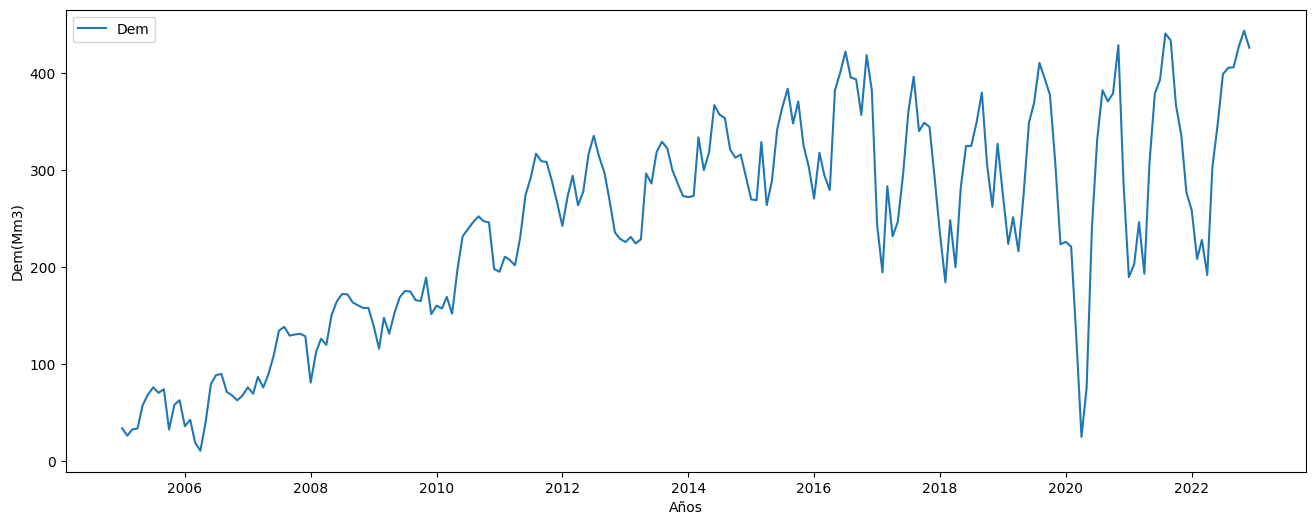

In [17]:
plt.figure(figsize = (16,6))
plt.title('', fontsize = 16)
plt.plot(df.ds, df.y, label = 'Dem')
plt.legend()
plt.xlabel('Años')
plt.ylabel('Dem(Mm3)')
plt.show()

In [18]:
# Eliminando valores atipicos
df.loc[(df['ds'] > '2020-02-28') & (df['ds'] < '2020-05-02'), 'y'] = None

In [19]:
# Se determina datos faltantes
df.isnull().sum()

ds    0
y     3
dtype: int64

In [20]:
# Determinación de la media 
df.describe()

,y
count,213.000000
mean,243.107502
std,108.435300
min,10.653000
25%,163.427000
50%,258.188000
75%,324.487000
max,443.330000


In [21]:
# Reemplazando los valores faltantes por la media
df['y'] = df['y'].replace(np.nan, 243.11)

In [22]:
# Se determina datos faltantes
df.isnull().sum()

ds    0
y     0
dtype: int64

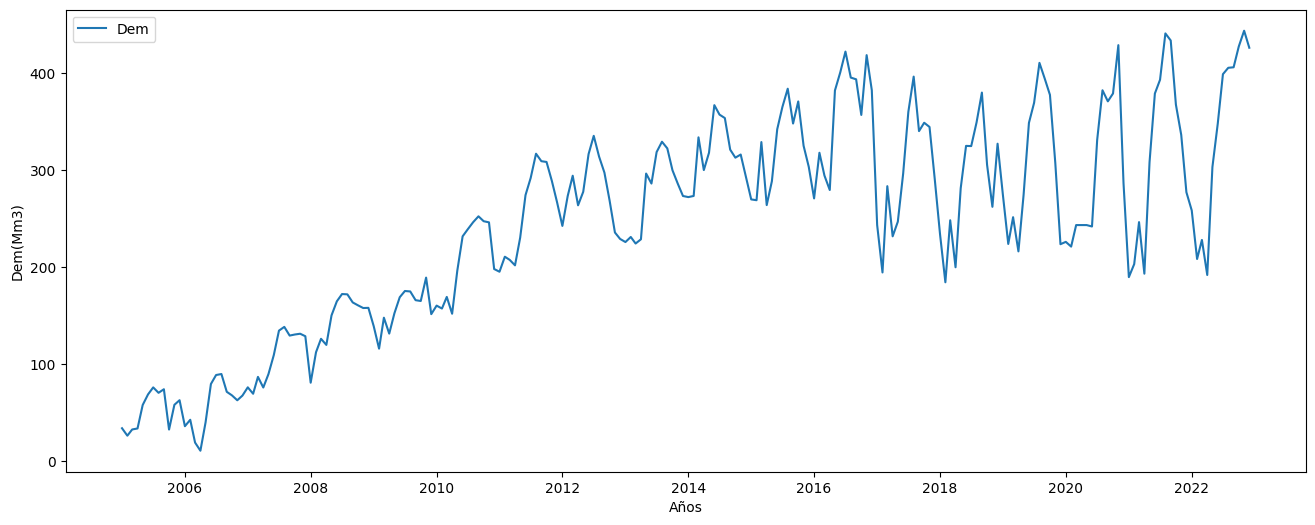

In [23]:
# Visualizacion de la serie sin valore atipicos
plt.figure(figsize = (16,6))
plt.title('', fontsize = 16)
plt.plot(df.ds, df.y, label = 'Dem')
plt.legend()
plt.xlabel('Años')
plt.ylabel('Dem(Mm3)')
plt.show()

In [24]:
# cambios manuales de hiperparametros
m = Prophet(seasonality_mode='multiplicative', changepoint_prior_scale= 0.05, seasonality_prior_scale= 1.0)

m.fit(df)   # ajuste del modelo al dataset de entrenamiento

06:39:38 - cmdstanpy - INFO - Chain [1] start processing
06:39:38 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
# validacion cruzada
from prophet.diagnostics import cross_validation
df_cv = cross_validation(m, initial='4745 days', period='90 days', horizon = '1460 days', parallel='processes')

In [26]:
# Calculo del MAPE
from prophet.diagnostics import performance_metrics
manual_model_p = performance_metrics(df_cv, rolling_window=1)
manual_model_p['mape'].values[0]

0.1515343090333655

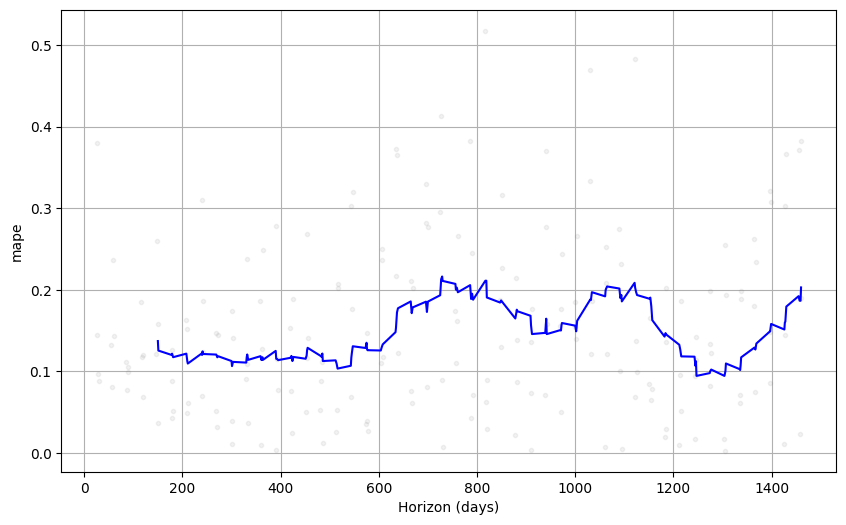

In [27]:
# Visualizacion de la metrica de rendimiento del modelo
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')

In [28]:
# Resultados de validacion cruzada
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2018-04-01,275.419412,244.423138,305.082198,199.646,2018-03-07
1,2018-05-01,318.372679,287.191002,351.678700,281.116,2018-03-07
2,2018-06-01,360.985580,328.604443,392.880389,324.680,2018-03-07
3,2018-07-01,384.506349,352.438336,416.216998,324.487,2018-03-07
4,2018-08-01,391.133948,361.014825,421.581111,348.871,2018-03-07


In [29]:
# Prediccion y visualizacion de datos pronosticados
future = m.make_future_dataframe(periods=60, freq='MS')

# Python
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
271,2027-08-01,407.504337,362.414963,450.698815
272,2027-09-01,390.999609,345.654095,435.426866
273,2027-10-01,375.964028,327.520472,422.685175
274,2027-11-01,357.379911,311.477780,403.543386
275,2027-12-01,321.366444,275.717543,366.722572


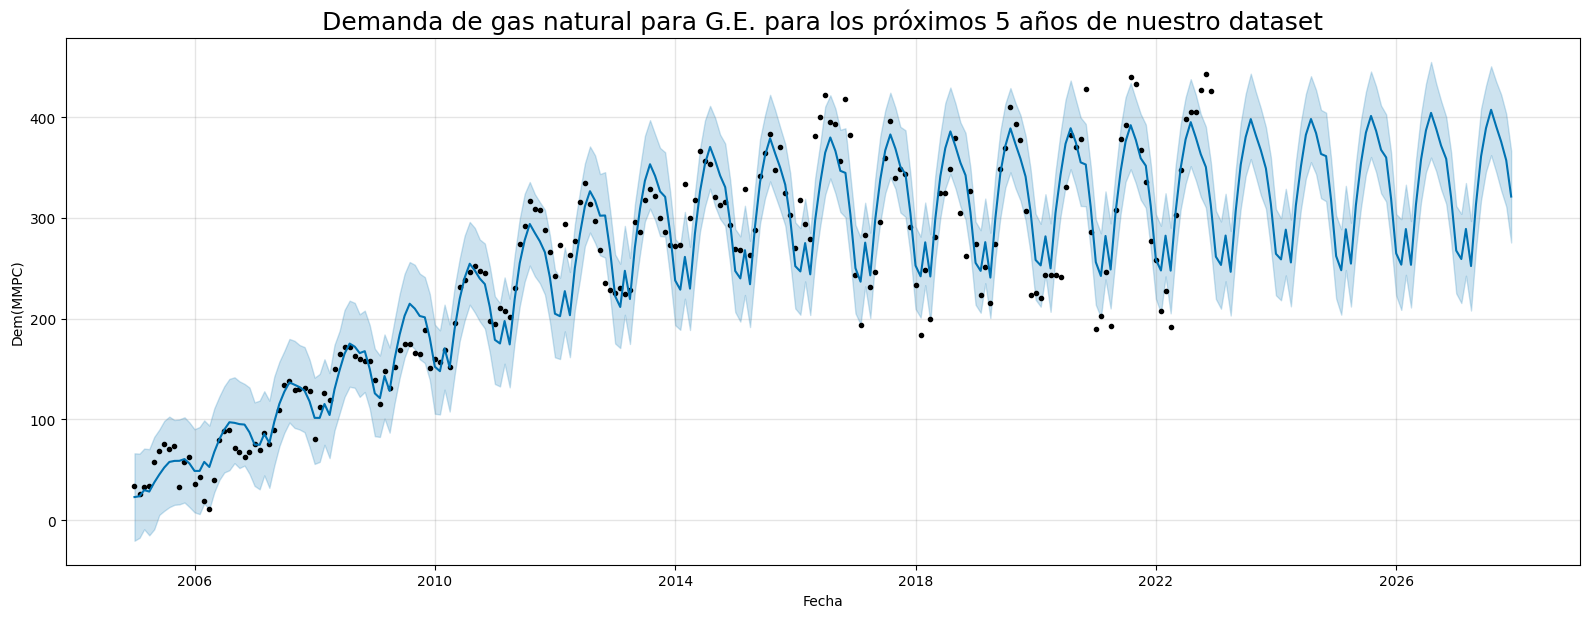

In [30]:
# plot forecasts
m.plot(forecast, xlabel='Fecha', ylabel='Dem(MMPC)', figsize = (16,6))
plt.title('Demanda de gas natural para G.E. para los próximos 5 años de nuestro dataset', fontsize = 18)
plt.show()

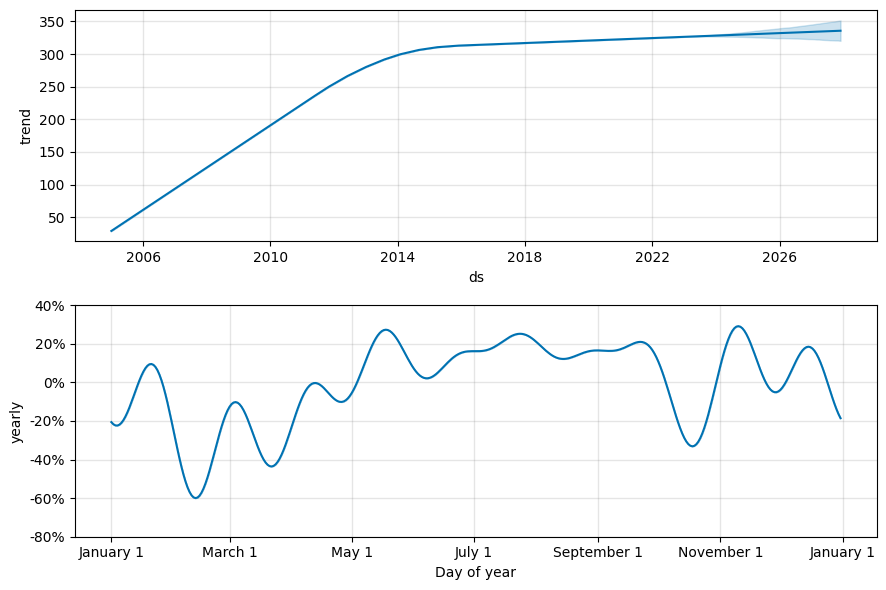

In [31]:
# Componentes del pronostico
fig2 = m.plot_components(forecast)

In [32]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(36)

,ds,yhat,yhat_lower,yhat_upper
0,2005-01-01,22.957161,-17.524268,66.317239
1,2005-02-01,23.781065,-21.018652,67.236836
2,2005-03-01,29.838565,-10.613563,73.022730
3,2005-04-01,28.423270,-15.368059,69.650667
4,2005-05-01,37.389639,-3.746839,75.578001
5,2005-06-01,45.333136,1.090476,86.560376
6,2005-07-01,52.260344,10.074813,96.240953
7,2005-08-01,57.819292,13.463231,99.294121
8,2005-09-01,58.862313,15.056502,100.647844
9,2005-10-01,58.932324,17.729469,100.454257


In [33]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(60)

,ds,yhat,yhat_lower,yhat_upper
216,2023-01-01,261.638854,220.454416,301.619023
217,2023-02-01,253.437075,214.293388,294.055190
218,2023-03-01,282.644501,242.297980,325.351087
219,2023-04-01,246.619953,204.071524,289.597463
220,2023-05-01,306.427660,264.665155,349.281115
221,2023-06-01,353.131259,313.774144,399.357583
222,2023-07-01,380.432313,338.720218,422.377401
223,2023-08-01,398.277348,355.318967,441.485689
224,2023-09-01,382.150583,340.652316,428.856761
225,2023-10-01,367.459236,326.762271,408.322869
